# Classical ML Training on the SR-BH 2020 Derived Dataset

This notebook trains and evaluates classical machine learning models on the POST-filtered SR-BH 2020 derived dataset.

## Workflow

1. Load and validate the dataset.
2. Clean duplicates and missing values.
3. Confirm that `request_type` only contains `POST` values.
4. Engineer handcrafted numerical features from `url` and `parameter`.
5. Create stratified train, validation, and test splits.
6. Scale only the handcrafted numerical features.
7. Train mandatory models: Logistic Regression, Linear SVM, and Random Forest.
8. Compare validation performance and select the best model using Macro F1.
9. Evaluate the selected model once on the test set and save confusion matrices to `models_output/`.



In [1]:
from pathlib import Path
from urllib.parse import unquote_plus
import math
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid")



DATASET_PATH = Path("../datasets/post_filtered_attack_dataset.csv")
OUTPUT_DIR = Path("models_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CLASS_NAMES = {
    0: "Normal",
    1: "SQL Injection",
    3: "OS Command Injection",
    4: "Code Injection",
}
HANDCRAFTED_FEATURES = [
    "url_length",
    "parameter_length",
    "parameter_count",
    "parameter_special_char_count",
    "parameter_digit_count",
    "parameter_alpha_count",
    "url_query_delimiter_count",
    "url_entropy",
    "parameter_entropy",
    "sql_keyword_count",
    "shell_keyword_count",
    "code_keyword_count",
]

## Load and Clean the Dataset

In [2]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns = [column.strip().lower() for column in df.columns]

required_columns = {"url", "parameter", "request_type", "label"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

initial_shape = df.shape
df = df.drop_duplicates().copy()
duplicates_removed = initial_shape[0] - len(df)

missing_before_fill = df[["url", "parameter", "request_type", "label"]].isna().sum().to_frame("missing_count")
df["url"] = df["url"].fillna("").astype(str)
df["parameter"] = df["parameter"].fillna("").astype(str)
df["request_type"] = df["request_type"].fillna("").astype(str).str.upper().str.strip()
df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

summary_df = pd.DataFrame(
    {
        "metric": ["initial_rows", "rows_after_dedup", "duplicates_removed"],
        "value": [initial_shape[0], len(df), duplicates_removed],
    }
)

display(summary_df)
display(missing_before_fill)
display(df.head())

,metric,value
0,initial_rows,19504
1,rows_after_dedup,18211
2,duplicates_removed,1293


,missing_count
url,0
parameter,0
request_type,0
label,0


,url,parameter,request_type,label
0,/blog/index.php/my-account/,username=rafael&password=espa%C3%B1a01&user-re...,POST,0
1,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=8...,POST,0
2,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=1...,POST,0
3,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=8...,POST,0
4,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=3...,POST,0


## Validate Request Type

In [3]:
request_type_counts = df["request_type"].value_counts(dropna=False).rename_axis("request_type").reset_index(name="count")
unexpected_request_types = sorted(set(df["request_type"].unique()) - {"POST"})

display(request_type_counts)
if unexpected_request_types:
    print("Unexpected request types found:", unexpected_request_types)
else:
    print("All request_type values are POST.")

,request_type,count
0,POST,18211


All request_type values are POST.


## Engineer Handcrafted Features

In [4]:
SQL_KEYWORDS = {
    "select", "union", "insert", "update", "delete", "drop", "where", "from",
    "or", "and", "sleep", "benchmark", "information_schema", "having", "order", "group",
}
SHELL_KEYWORDS = {
    "cmd", "powershell", "bash", "sh", "wget", "curl", "chmod", "cat", "whoami",
    "ping", "nc", "netcat", "python", "perl", "php", "rm", "uname",
}
CODE_KEYWORDS = {
    "eval", "exec", "system", "assert", "base64_decode", "shell_exec", "passthru",
    "<?php", "script", "javascript", "onerror", "onload", "import", "subprocess", "runtime",
}
TOKEN_PATTERN = re.compile(r"[A-Za-z_]+")

def safe_unquote(value: str) -> str:
    try:
        return unquote_plus(value)
    except Exception:
        return value

def shannon_entropy(text: str) -> float:
    if not text:
        return 0.0
    counts = Counter(text)
    length = len(text)
    return float(-sum((count / length) * math.log2(count / length) for count in counts.values()))

def count_keywords(text: str, keywords: set[str]) -> int:
    decoded_text = safe_unquote(text).lower()
    tokens = TOKEN_PATTERN.findall(decoded_text)
    token_matches = sum(token in keywords for token in tokens)
    substring_matches = sum(decoded_text.count(keyword) for keyword in keywords if len(keyword) > 2 and keyword in decoded_text)
    return int(max(token_matches, substring_matches))

def build_handcrafted_features(frame: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame(index=frame.index)
    decoded_parameter = frame["parameter"].map(safe_unquote)
    decoded_url = frame["url"].map(safe_unquote)

    features["url_length"] = frame["url"].str.len()
    features["parameter_length"] = frame["parameter"].str.len()
    features["parameter_count"] = frame["parameter"].map(lambda value: 0 if not value else value.count("=") + value.count("&") + 1)
    features["parameter_special_char_count"] = decoded_parameter.str.count(r"[^A-Za-z0-9\s]")
    features["parameter_digit_count"] = decoded_parameter.str.count(r"\d")
    features["parameter_alpha_count"] = decoded_parameter.str.count(r"[A-Za-z]")
    features["url_query_delimiter_count"] = frame["url"].str.count(r"[\?&=]")
    features["url_entropy"] = decoded_url.map(shannon_entropy)
    features["parameter_entropy"] = decoded_parameter.map(shannon_entropy)
    features["sql_keyword_count"] = frame["parameter"].map(lambda value: count_keywords(value, SQL_KEYWORDS))
    features["shell_keyword_count"] = frame["parameter"].map(lambda value: count_keywords(value, SHELL_KEYWORDS))
    features["code_keyword_count"] = frame["parameter"].map(lambda value: count_keywords(value, CODE_KEYWORDS))
    return features


In [5]:
X_handcrafted = build_handcrafted_features(df)
y = df["label"].copy()

feature_preview = pd.concat([df[["url", "parameter", "label"]].head(), X_handcrafted.head()], axis=1)
display(feature_preview)
display(X_handcrafted.describe().T)

,url,parameter,label,url_length,parameter_length,parameter_count,parameter_special_char_count,parameter_digit_count,parameter_alpha_count,url_query_delimiter_count,url_entropy,parameter_entropy,sql_keyword_count,shell_keyword_count,code_keyword_count
0,/blog/index.php/my-account/,username=rafael&password=espa%C3%B1a01&user-re...,0,27,154,12,24,6,111,0,4.162295,4.667921,0,1,0
1,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=8...,0,26,64,8,10,3,50,0,3.825252,4.120657,0,0,0
2,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=1...,0,26,64,8,10,3,50,0,3.825252,4.120657,0,0,0
3,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=8...,0,26,64,8,10,3,50,0,3.825252,4.120657,0,0,0
4,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=3...,0,26,64,8,10,3,50,0,3.825252,4.120657,0,0,0


,count,mean,std,min,25%,50%,75%,max
url_length,18211.0,50.520564,36.643099,1.000000,29.000000,40.000000,59.000000,583.000000
parameter_length,18211.0,198.558289,102.308676,19.000000,138.000000,191.000000,240.000000,613.000000
parameter_count,18211.0,12.576739,4.797237,1.000000,8.000000,14.000000,14.000000,22.000000
parameter_special_char_count,18211.0,32.386525,17.984752,6.000000,22.000000,29.000000,40.000000,140.000000
parameter_digit_count,18211.0,9.364560,8.981299,0.000000,4.000000,6.000000,12.000000,54.000000
parameter_alpha_count,18211.0,137.543298,66.463512,9.000000,99.000000,143.000000,164.000000,367.000000
url_query_delimiter_count,18211.0,0.794410,1.194263,0.000000,0.000000,0.000000,2.000000,12.000000
url_entropy,18211.0,4.253858,0.327761,-0.000000,4.113206,4.256198,4.485128,5.314266
parameter_entropy,18211.0,4.754755,0.175292,3.711209,4.664749,4.768303,4.880245,5.201340
sql_keyword_count,18211.0,0.431717,0.807700,0.000000,0.000000,0.000000,1.000000,4.000000


## Stratified Train / Validation / Test Split

In [6]:
X_train_num, X_temp_num, y_train, y_temp, train_idx, temp_idx = train_test_split(
    X_handcrafted,
    y,
    df.index,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val_num, X_test_num, y_val, y_test, val_idx, test_idx = train_test_split(
    X_temp_num,
    y_temp,
    temp_idx,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_overview = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train_num), len(X_val_num), len(X_test_num)],
        "ratio": [len(X_train_num) / len(df), len(X_val_num) / len(df), len(X_test_num) / len(df)],
    }
)
display(split_overview)

split_label_distribution = pd.concat(
    {
        "train": y_train.value_counts(normalize=True).sort_index(),
        "validation": y_val.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    },
    axis=1,
).fillna(0.0)
split_label_distribution.index = split_label_distribution.index.map(CLASS_NAMES)
display(split_label_distribution)

,split,rows,ratio
0,train,12747,0.699962
1,validation,2732,0.150019
2,test,2732,0.150019


,train,validation,test
label,,,
Normal,0.145289,0.144949,0.145315
SQL Injection,0.506864,0.506955,0.506955
OS Command Injection,0.245940,0.245974,0.245974
Code Injection,0.101906,0.102123,0.101757


## Scale Handcrafted Features and Prepare Optional TF-IDF Ablation

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_val_scaled = scaler.transform(X_val_num)
X_test_scaled = scaler.transform(X_test_num)

train_text = (df.loc[train_idx, "url"].fillna("") + " " + df.loc[train_idx, "parameter"].fillna(""))
val_text = (df.loc[val_idx, "url"].fillna("") + " " + df.loc[val_idx, "parameter"].fillna(""))
test_text = (df.loc[test_idx, "url"].fillna("") + " " + df.loc[test_idx, "parameter"].fillna(""))

tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=3000,
)
X_train_tfidf = tfidf.fit_transform(train_text)
X_val_tfidf = tfidf.transform(val_text)
X_test_tfidf = tfidf.transform(test_text)

X_train_handcrafted_sparse = csr_matrix(X_train_scaled)
X_val_handcrafted_sparse = csr_matrix(X_val_scaled)
X_test_handcrafted_sparse = csr_matrix(X_test_scaled)

X_train_hc_tfidf = hstack([X_train_handcrafted_sparse, X_train_tfidf], format="csr")
X_val_hc_tfidf = hstack([X_val_handcrafted_sparse, X_val_tfidf], format="csr")
X_test_hc_tfidf = hstack([X_test_handcrafted_sparse, X_test_tfidf], format="csr")

X_train_tfidf_only = X_train_tfidf
X_val_tfidf_only = X_val_tfidf
X_test_tfidf_only = X_test_tfidf

# Random Forest works more reliably with dense matrices for these derived feature sets.
X_train_hc_tfidf_dense = X_train_hc_tfidf.toarray()
X_val_hc_tfidf_dense = X_val_hc_tfidf.toarray()
X_test_hc_tfidf_dense = X_test_hc_tfidf.toarray()
X_train_tfidf_only_dense = X_train_tfidf_only.toarray()
X_val_tfidf_only_dense = X_val_tfidf_only.toarray()
X_test_tfidf_only_dense = X_test_tfidf_only.toarray()

print("Scaled handcrafted train shape:", X_train_scaled.shape)
print("Handcrafted + TF-IDF train shape:", X_train_hc_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))

Scaled handcrafted train shape: (12747, 12)
Handcrafted + TF-IDF train shape: (12747, 3012)
TF-IDF vocabulary size: 3000


## Train Models and Compare on the Validation Set

In [8]:
def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }

model_runs = [
    {
        "model_name": "Logistic Regression",
        "feature_set": "Handcrafted",
        "model": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_scaled,
        "X_val": X_val_scaled,
        "X_test": X_test_scaled,
    },
    {
        "model_name": "Linear SVM",
        "feature_set": "Handcrafted",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_scaled,
        "X_val": X_val_scaled,
        "X_test": X_test_scaled,
    },
    {
        "model_name": "Random Forest",
        "feature_set": "Handcrafted",
        "model": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "X_train": X_train_num,
        "X_val": X_val_num,
        "X_test": X_test_num,
    },
    {
        "model_name": "Random Forest",
        "feature_set": "Handcrafted + TF-IDF",
        "model": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "X_train": X_train_hc_tfidf_dense,
        "X_val": X_val_hc_tfidf_dense,
        "X_test": X_test_hc_tfidf_dense,
    },
    {
        "model_name": "Random Forest",
        "feature_set": "TF-IDF Only",
        "model": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "X_train": X_train_tfidf_only_dense,
        "X_val": X_val_tfidf_only_dense,
        "X_test": X_test_tfidf_only_dense,
    },
    {
        "model_name": "Logistic Regression",
        "feature_set": "Handcrafted + TF-IDF",
        "model": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_hc_tfidf,
        "X_val": X_val_hc_tfidf,
        "X_test": X_test_hc_tfidf,
    },
    {
        "model_name": "Linear SVM",
        "feature_set": "Handcrafted + TF-IDF",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_hc_tfidf,
        "X_val": X_val_hc_tfidf,
        "X_test": X_test_hc_tfidf,
    },
    {
        "model_name": "Logistic Regression",
        "feature_set": "TF-IDF Only",
        "model": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_tfidf_only,
        "X_val": X_val_tfidf_only,
        "X_test": X_test_tfidf_only,
    },
    {
        "model_name": "Linear SVM",
        "feature_set": "TF-IDF Only",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_tfidf_only,
        "X_val": X_val_tfidf_only,
        "X_test": X_test_tfidf_only,
    },
]

trained_runs = []
validation_rows = []

for run in model_runs:
    estimator = run["model"]
    estimator.fit(run["X_train"], y_train)
    val_pred = estimator.predict(run["X_val"])
    metrics = evaluate_predictions(y_val, val_pred)
    validation_rows.append(
        {
            "model_name": run["model_name"],
            "feature_set": run["feature_set"],
            **metrics,
        }
    )
    trained_runs.append({**run, "estimator": estimator, "validation_predictions": val_pred, "validation_metrics": metrics})

validation_results = pd.DataFrame(validation_rows).sort_values(
    by=["macro_f1", "weighted_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)
display(validation_results)

,model_name,feature_set,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Linear SVM,Handcrafted + TF-IDF,0.837482,0.785658,0.864331,0.807111,0.873512,0.837482,0.844190
1,Linear SVM,TF-IDF Only,0.827599,0.774790,0.857767,0.798688,0.863840,0.827599,0.834242
2,Logistic Regression,Handcrafted + TF-IDF,0.808565,0.761852,0.848690,0.782332,0.855738,0.808565,0.816461
3,Logistic Regression,TF-IDF Only,0.801245,0.752755,0.843469,0.776470,0.845561,0.801245,0.808397
4,Random Forest,TF-IDF Only,0.783309,0.712316,0.730094,0.718853,0.794117,0.783309,0.787335
5,Random Forest,Handcrafted + TF-IDF,0.775256,0.692561,0.700762,0.696143,0.780387,0.775256,0.777508
6,Random Forest,Handcrafted,0.729502,0.655465,0.645109,0.649338,0.730455,0.729502,0.729252
7,Linear SVM,Handcrafted,0.641288,0.608098,0.680899,0.620778,0.662729,0.641288,0.635945
8,Logistic Regression,Handcrafted,0.582723,0.565532,0.668904,0.583162,0.631559,0.582723,0.580677


## Select the Best Validation Model

In [9]:
best_row = validation_results.iloc[0]
best_run = next(
    run
    for run in trained_runs
    if run["model_name"] == best_row["model_name"] and run["feature_set"] == best_row["feature_set"]
)

best_summary = pd.DataFrame(
    {
        "selected_model": [best_row["model_name"]],
        "feature_set": [best_row["feature_set"]],
        "validation_macro_f1": [best_row["macro_f1"]],
        "validation_weighted_f1": [best_row["weighted_f1"]],
        "validation_accuracy": [best_row["accuracy"]],
    }
)
display(best_summary)

,selected_model,feature_set,validation_macro_f1,validation_weighted_f1,validation_accuracy
0,Linear SVM,Handcrafted + TF-IDF,0.807111,0.84419,0.837482


## Evaluate the Selected Model on the Test Set

In [10]:
test_pred = best_run["estimator"].predict(best_run["X_test"])
test_metrics = evaluate_predictions(y_test, test_pred)
test_metrics_df = pd.DataFrame([test_metrics])
display(test_metrics_df)

report_dict = classification_report(
    y_test,
    test_pred,
    labels=sorted(CLASS_NAMES),
    target_names=[CLASS_NAMES[label] for label in sorted(CLASS_NAMES)],
    output_dict=True,
    zero_division=0,
)
test_report_df = pd.DataFrame(report_dict).T
display(test_report_df)

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,0.841874,0.791798,0.873582,0.815167,0.87544,0.841874,0.847896


,precision,recall,f1-score,support
Normal,0.720930,0.937028,0.814896,397.000000
SQL Injection,0.970263,0.824549,0.891491,1385.000000
OS Command Injection,0.891753,0.772321,0.827751,672.000000
Code Injection,0.584245,0.960432,0.726531,278.000000
accuracy,0.841874,0.841874,0.841874,0.841874
macro avg,0.791798,0.873582,0.815167,2732.000000
weighted avg,0.875440,0.841874,0.847896,2732.000000


## Save Confusion Matrices

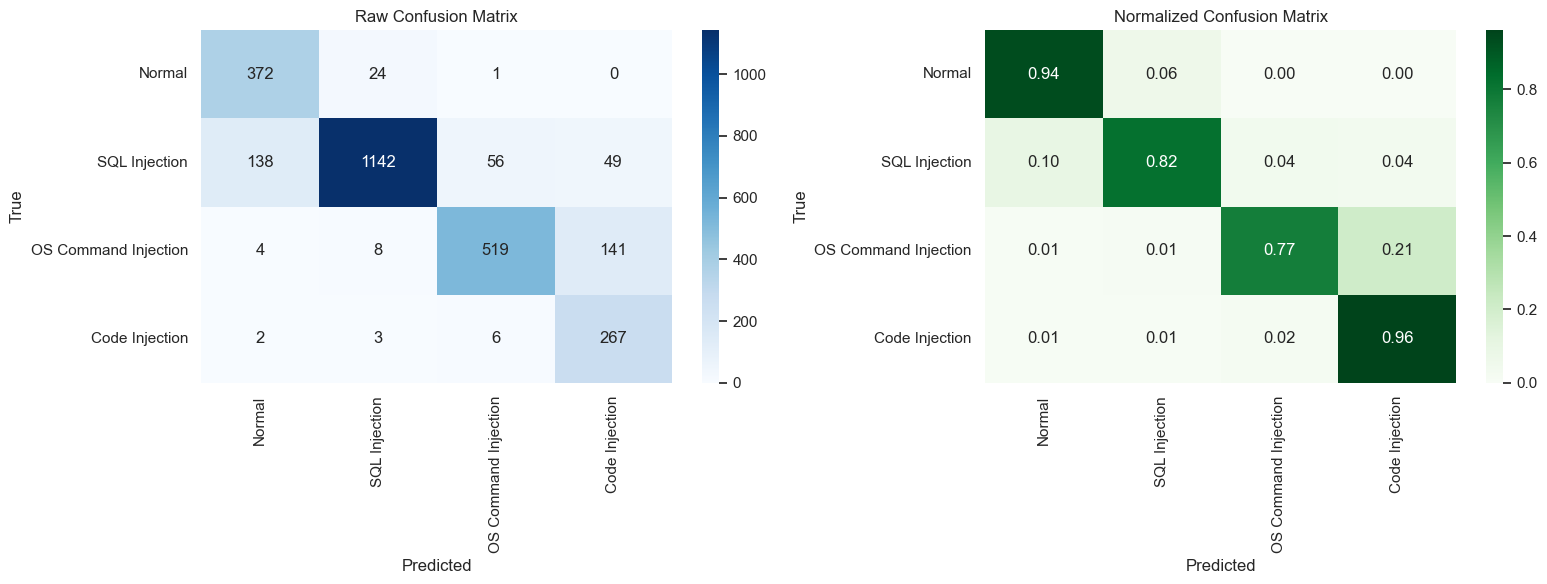

Saved confusion matrices to: models_output\best_model_confusion_matrices.png


In [11]:
labels_sorted = sorted(CLASS_NAMES)
class_labels = [CLASS_NAMES[label] for label in labels_sorted]
cm_raw = confusion_matrix(y_test, test_pred, labels=labels_sorted)
cm_normalized = confusion_matrix(y_test, test_pred, labels=labels_sorted, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title("Raw Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
confusion_path = OUTPUT_DIR / "best_model_confusion_matrices.png"
plt.savefig(confusion_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrices to: {confusion_path}")

## Handcrafted Feature Signal

,feature,overall_mean,std,range_across_class_means
1,parameter_length,198.558289,102.308676,90.454864
5,parameter_alpha_count,137.543298,66.463512,52.592858
0,url_length,50.520564,36.643099,52.133953
3,parameter_special_char_count,32.386525,17.984752,18.450036
4,parameter_digit_count,9.364560,8.981299,8.441452
2,parameter_count,12.576739,4.797237,3.009304
10,shell_keyword_count,0.828181,0.665597,0.856317
11,code_keyword_count,0.150678,0.498682,0.739158
9,sql_keyword_count,0.431717,0.807700,0.674849
7,url_entropy,4.253858,0.327761,0.251996


C:\Users\eEren\AppData\Local\Temp\ipykernel_1724\1167766302.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_signal_df.head(10), x="range_across_class_means", y="feature", palette="viridis")


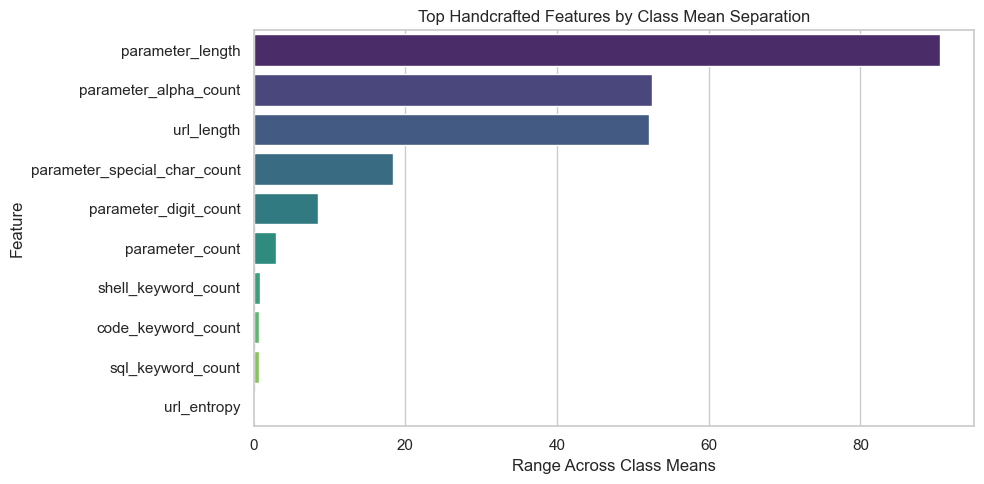

Saved handcrafted feature signal figure to: models_output\handcrafted_feature_signal.png


In [12]:
feature_signal = []
for feature_name in HANDCRAFTED_FEATURES:
    grouped_means = df.assign(**{feature_name: X_handcrafted[feature_name]}).groupby("label")[feature_name].mean()
    feature_signal.append(
        {
            "feature": feature_name,
            "overall_mean": X_handcrafted[feature_name].mean(),
            "std": X_handcrafted[feature_name].std(),
            "range_across_class_means": grouped_means.max() - grouped_means.min(),
        }
    )

feature_signal_df = pd.DataFrame(feature_signal).sort_values("range_across_class_means", ascending=False)
display(feature_signal_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_signal_df.head(10), x="range_across_class_means", y="feature", palette="viridis")
plt.title("Top Handcrafted Features by Class Mean Separation")
plt.xlabel("Range Across Class Means")
plt.ylabel("Feature")
plt.tight_layout()
feature_signal_path = OUTPUT_DIR / "handcrafted_feature_signal.png"
plt.savefig(feature_signal_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved handcrafted feature signal figure to: {feature_signal_path}")

## Final Report

In [13]:
per_class_f1 = test_report_df.loc[class_labels, "f1-score"].sort_values(ascending=False)

tfidf_comparison_rows = []
for model_name in ["Logistic Regression", "Linear SVM", "Random Forest"]:
    subset = validation_results[validation_results["model_name"] == model_name].set_index("feature_set")
    if {"Handcrafted", "Handcrafted + TF-IDF", "TF-IDF Only"}.issubset(subset.index):
        tfidf_comparison_rows.append(
            {
                "model_name": model_name,
                "handcrafted_macro_f1": subset.loc["Handcrafted", "macro_f1"],
                "handcrafted_plus_tfidf_macro_f1": subset.loc["Handcrafted + TF-IDF", "macro_f1"],
                "tfidf_only_macro_f1": subset.loc["TF-IDF Only", "macro_f1"],
            }
        )

tfidf_comparison_df = pd.DataFrame(tfidf_comparison_rows)
display(tfidf_comparison_df)

best_train_macro_f1 = None
if hasattr(best_run["estimator"], "predict"):
    train_pred = best_run["estimator"].predict(best_run["X_train"])
    best_train_macro_f1 = f1_score(y_train, train_pred, average="macro")

report_answers = pd.DataFrame(
    {
        "question": [
            "Which model performed best?",
            "Which class had the highest F1-score?",
            "Which class had the lowest F1-score?",
            "Did handcrafted features help?",
            "Did TF-IDF features help?",
            "Are there signs of overfitting?",
            "What should be improved in the dataset or features?",
        ],
        "answer": [
            f"{best_row['model_name']} with {best_row['feature_set']} achieved the best validation Macro F1 of {best_row['macro_f1']:.4f}.",
            f"{per_class_f1.index[0]} had the highest test F1-score at {per_class_f1.iloc[0]:.4f}.",
            f"{per_class_f1.index[-1]} had the lowest test F1-score at {per_class_f1.iloc[-1]:.4f}.",
            "Yes. Handcrafted features provided the core signal for every mandatory model and produced a strong non-text baseline.",
            (
                "Yes, if the Handcrafted + TF-IDF variants improved Macro F1 over Handcrafted-only runs in the comparison table; otherwise no meaningful gain was observed."
                if not tfidf_comparison_df.empty else
                "TF-IDF benefit could not be assessed because the comparison table was empty."
            ),
            (
                f"Potential overfitting exists if the selected model's training Macro F1 ({best_train_macro_f1:.4f}) is materially higher than validation Macro F1 ({best_row['macro_f1']:.4f})."
                if best_train_macro_f1 is not None else
                "Training-vs-validation overfitting check could not be computed."
            ),
            "Improve class balance, add more diverse attack payloads, refine keyword dictionaries, and consider richer structural features from parameter parsing."
        ],
    }
)
display(report_answers)

,model_name,handcrafted_macro_f1,handcrafted_plus_tfidf_macro_f1,tfidf_only_macro_f1
0,Logistic Regression,0.583162,0.782332,0.776470
1,Linear SVM,0.620778,0.807111,0.798688
2,Random Forest,0.649338,0.696143,0.718853


,question,answer
0,Which model performed best?,Linear SVM with Handcrafted + TF-IDF achieved ...
1,Which class had the highest F1-score?,SQL Injection had the highest test F1-score at...
2,Which class had the lowest F1-score?,Code Injection had the lowest test F1-score at...
3,Did handcrafted features help?,Yes. Handcrafted features provided the core si...
4,Did TF-IDF features help?,"Yes, if the Handcrafted + TF-IDF variants impr..."
5,Are there signs of overfitting?,Potential overfitting exists if the selected m...
6,What should be improved in the dataset or feat...,"Improve class balance, add more diverse attack..."
